# RetinaNet + 2x YOLO Ensemble

- 기존에 학습한 가중치만 사용해서 `RetinaNet 1개 + YOLO 2개 + WBF` 앙상블을 실행합니다.
- 환경 설정은 프로젝트 `requirements.txt`, 데이터 로드는 기존 `get_loaders()` 흐름을 그대로 사용합니다.
  1. 환경 / 경로 설정
  2. 공통 import 및 데이터 로드
  3. RetinaNet / YOLO / WBF helper 정의
  4. 가중치 로드
  5. test submission CSV 생성
  6. validation 클래스별 AP 계산
  7. validation 시각화
- 실행 전에 꼭 확인할 값은: `BASE_DIR`, `RETINANET_WEIGHTS_PATH`, `YOLO_MODEL_SPECS`


In [1]:
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

PROJECT_DIR = "/content/pill_detection_project" if IN_COLAB else os.getcwd()

if IN_COLAB and not os.path.isdir(PROJECT_DIR):
    subprocess.run(
        ["git", "clone", "https://github.com/wina0901/pill_detection_project.git", PROJECT_DIR],
        check=True,
    )

os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

REQUIREMENTS_PATH = os.path.join(PROJECT_DIR, "requirements.txt")
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "pip"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-r", REQUIREMENTS_PATH], check=True)
else:
    print("로컬 환경에서는 requirements.txt 자동 설치를 생략합니다.")

print("PROJECT_DIR:", PROJECT_DIR)
print("IN_COLAB:", IN_COLAB)
print("REQUIREMENTS_PATH:", REQUIREMENTS_PATH)


Mounted at /content/drive
PROJECT_DIR: /content/pill_detection_project
IN_COLAB: True
REQUIREMENTS_PATH: /content/pill_detection_project/requirements.txt


In [2]:
import io
import json
import math
import contextlib
import random
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as fm

from PIL import Image
from IPython.display import display
from matplotlib.font_manager import FontProperties
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchvision.ops import sigmoid_focal_loss, box_iou, nms
from ultralytics import YOLO
from pycocotools.coco import COCO

from src.preprocessing.dataset import get_loaders
from src.evaluation.evaluation import compute_coco_map

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
YOLO_DEVICE = 0 if torch.cuda.is_available() else "cpu"

BASE_DIR = "/content/drive/MyDrive/data/초급_프로젝트/dataset" if IN_COLAB else str(Path(PROJECT_DIR) / "data")

RETINANET_WEIGHTS_PATH = "/content/drive/MyDrive/pill_detection_outputs/retinanet_v9.pth" if IN_COLAB else str(Path(PROJECT_DIR) / "retinanet_oral_drug.pth")

YOLO_MODEL_SPECS = [
    {
        "name": "yolo11m_v2_v3_ft_uf_lr_0p0005",
        "weights_path": "/content/drive/MyDrive/pill_detection_outputs/yolo11m_v2_v3_ft_uf_lr_0p0005_best.pt" if IN_COLAB else str(Path(PROJECT_DIR) / "models" / "yolo" / "yolo11m_v2_v3_ft_uf_lr_0p0005_best.pt"),
        "ensemble_weight": 1.0,
    },
    {
        "name": "yolov8s_v2_v3_ft_uf_lr_0p0003",
        "weights_path": "/content/drive/MyDrive/pill_detection_outputs/yolov8s_v2_v3_ft_uf_lr_0p0003_best.pt" if IN_COLAB else str(Path(PROJECT_DIR) / "models" / "yolo" / "yolov8s_v2_v3_ft_uf_lr_0p0003_best.pt"),
        "ensemble_weight": 1.0,
    },
]

TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")
OUTPUT_CSV_PATH = "/content/pill_detection_project/retinanet_yolo_ensemble_submission.csv" if IN_COLAB else str(Path(PROJECT_DIR) / "retinanet_yolo_ensemble_submission.csv")

LETTERBOX_TARGET_SIZE = 800
RETINANET_SCORE_THRESHOLD = 0.05
YOLO_SCORE_THRESHOLD = 0.05
YOLO_INTERNAL_IOU = 0.85

RETINANET_WEIGHT = 1.0

ENSEMBLE_WBF_IOU = 0.55
ENSEMBLE_SCORE_REDUCTION = "mean"  # "mean" or "max"
TOP_K_PER_IMAGE = 4
POST_WBF_AGNOSTIC_NMS_IOU = None  # 예: 0.50, 비활성화는 None
CATEGORY_ID_OFFSET = 1

VAL_AP_IMAGE_LIMIT = None  # 디버깅 시 정수로 제한 가능
ENSEMBLE_NUM_SAMPLES = 6
ENSEMBLE_VIS_MIN_SCORE = 0.0

VAL_SWEEP_RETINANET_THRESHOLDS = [0.05, 0.10, 0.15, 0.20]
VAL_SWEEP_YOLO_THRESHOLDS = [0.05, 0.10, 0.15, 0.20]
VAL_SWEEP_WBF_IOUS = [0.50, 0.55]
VAL_SWEEP_SCORE_REDUCTIONS = ["mean", "max"]
VAL_SWEEP_TOP_KS = [4]
VAL_SWEEP_POST_WBF_AGNOSTIC_NMS_IOUS = [None, 0.50]
RANDOM_SEED = 42

if not os.path.isdir(BASE_DIR):
    raise FileNotFoundError(f"BASE_DIR를 찾을 수 없습니다: {BASE_DIR}")
if not YOLO_MODEL_SPECS:
    raise ValueError("YOLO_MODEL_SPECS가 비어 있습니다. 최소 1개 이상의 YOLO 가중치를 지정해주세요.")

train_loader, val_loader, orig2model, num_classes, VAL_JSON_PATH = get_loaders(
    base_dir=BASE_DIR,
    batch_size=4,
    num_workers=2,
)

retinanet_model2orig = {v: k for k, v in orig2model.items()}
yolo_idx2orig = {idx: cat_id for idx, cat_id in enumerate(sorted(orig2model.keys()))}

retinanet_label2submit = {
    model_label: int(orig_cat + CATEGORY_ID_OFFSET)
    for model_label, orig_cat in retinanet_model2orig.items()
}
yolo_label2submit = {
    yolo_label: int(orig_cat + CATEGORY_ID_OFFSET)
    for yolo_label, orig_cat in yolo_idx2orig.items()
}

with open(VAL_JSON_PATH, "r", encoding="utf-8") as f:
    val_coco = json.load(f)

cat_id_to_name = {c["id"]: c["name"] for c in val_coco["categories"]}

print("DEVICE:", DEVICE)
print("YOLO_DEVICE:", YOLO_DEVICE)
print("BASE_DIR:", BASE_DIR)
print("VAL_JSON_PATH:", VAL_JSON_PATH)
print("num_classes:", num_classes)
print("train images:", len(train_loader.dataset.image_ids))
print("val images:", len(val_loader.dataset.image_ids))
print("YOLO ensemble specs:")
for spec in YOLO_MODEL_SPECS:
    print(f"  - {spec['name']}: {spec['weights_path']} (weight={spec['ensemble_weight']})")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ 고유 클래스 수  : 73종
✅ num_classes     : 74  ← 모델 정의 시 사용
✅ Train: 4499장 / 11348개
✅ Val  : 328장 / 622개
DEVICE: cuda
YOLO_DEVICE: 0
BASE_DIR: /content/drive/MyDrive/data/초급_프로젝트/dataset
VAL_JSON_PATH: /content/drive/MyDrive/data/초급_프로젝트/dataset/val_letterbox.json
num_classes: 74
train images: 4499
val images: 328
YOLO ensemble specs:
  - yolo11m_v2_v3_ft_uf_lr_0p0005: /content/drive/MyDrive/pill_detection_outputs/yolo11m_v2_v3_ft_uf_lr_0p0005_best.pt (weight=1.0)
  - yolov8s_v2_v3_ft_uf_lr_0p0003: /content/drive/MyDrive/pill_detection_outputs/yolov8s_v2_v3_ft_uf_lr_0p0003_best.pt (weight=1.0)


In [3]:
class CustomRetinaNetClassificationHead(RetinaNetClassificationHead):
    def __init__(self, in_channels, num_anchors, num_classes, alpha=0.25, gamma=2.0, norm_layer=None):
        super().__init__(in_channels, num_anchors, num_classes, norm_layer=norm_layer)
        self.focal_alpha = alpha
        self.focal_gamma = gamma

    def compute_loss(self, targets, head_outputs, matched_idxs):
        cls_logits = head_outputs["cls_logits"]
        losses = []

        for targets_per_image, cls_logits_per_image, matched_idxs_per_image in zip(targets, cls_logits, matched_idxs):
            foreground_idxs_per_image = matched_idxs_per_image >= 0
            num_foreground = foreground_idxs_per_image.sum().item()

            gt_classes_target = torch.zeros_like(cls_logits_per_image)
            if num_foreground > 0:
                gt_classes_target[
                    foreground_idxs_per_image,
                    targets_per_image["labels"][matched_idxs_per_image[foreground_idxs_per_image]],
                ] = 1.0

            valid_idxs_per_image = matched_idxs_per_image != self.BETWEEN_THRESHOLDS

            losses.append(
                sigmoid_focal_loss(
                    cls_logits_per_image[valid_idxs_per_image],
                    gt_classes_target[valid_idxs_per_image],
                    alpha=self.focal_alpha,
                    gamma=self.focal_gamma,
                    reduction="sum",
                ) / max(1, num_foreground)
            )

        return sum(losses) / len(targets)


def build_retinanet_model(num_classes, focal_alpha=None, focal_gamma=None):
    model = retinanet_resnet50_fpn(weights="DEFAULT")
    cls_head = model.head.classification_head

    first_conv = next(module for module in cls_head.conv.modules() if isinstance(module, nn.Conv2d))
    in_channels = first_conv.in_channels
    num_anchors = cls_head.num_anchors

    if focal_alpha is None and focal_gamma is None:
        model.head.classification_head = RetinaNetClassificationHead(
            in_channels=in_channels,
            num_anchors=num_anchors,
            num_classes=num_classes,
        )
    else:
        focal_alpha = 0.25 if focal_alpha is None else focal_alpha
        focal_gamma = 2.0 if focal_gamma is None else focal_gamma

        custom_head = CustomRetinaNetClassificationHead(
            in_channels=in_channels,
            num_anchors=num_anchors,
            num_classes=num_classes,
            alpha=focal_alpha,
            gamma=focal_gamma,
        )
        prior_probability = 0.01
        torch.nn.init.constant_(
            custom_head.cls_logits.bias,
            -math.log((1 - prior_probability) / prior_probability),
        )
        model.head.classification_head = custom_head

    return model


def make_empty_prediction():
    return {
        "boxes": torch.empty((0, 4), dtype=torch.float32),
        "scores": torch.empty((0,), dtype=torch.float32),
        "labels": torch.empty((0,), dtype=torch.int64),
    }


def letterbox_pil_for_ensemble(image, target_size=800, fill=(114, 114, 114)):
    orig_w, orig_h = image.size
    scale = target_size / max(orig_w, orig_h)
    new_w = max(1, int(orig_w * scale))
    new_h = max(1, int(orig_h * scale))

    resized = image.resize((new_w, new_h), Image.BILINEAR)
    padded = Image.new("RGB", (target_size, target_size), fill)

    pad_left = (target_size - new_w) // 2
    pad_top = (target_size - new_h) // 2
    padded.paste(resized, (pad_left, pad_top))

    meta = {
        "orig_w": orig_w,
        "orig_h": orig_h,
        "scale": scale,
        "pad_left": pad_left,
        "pad_top": pad_top,
    }
    return padded, meta


def restore_boxes_to_original_xyxy(boxes, meta):
    if boxes.numel() == 0:
        return boxes

    restored = boxes.clone().float()
    restored[:, [0, 2]] = (restored[:, [0, 2]] - meta["pad_left"]) / meta["scale"]
    restored[:, [1, 3]] = (restored[:, [1, 3]] - meta["pad_top"]) / meta["scale"]
    restored[:, [0, 2]] = restored[:, [0, 2]].clamp(0, meta["orig_w"])
    restored[:, [1, 3]] = restored[:, [1, 3]].clamp(0, meta["orig_h"])
    return restored


def fuse_cluster(cluster_boxes, cluster_scores, score_reduction="mean"):
    cluster_boxes = torch.stack(cluster_boxes).float()
    cluster_scores = torch.stack(cluster_scores).float()

    weights = cluster_scores.unsqueeze(1).clamp_min(1e-6)
    fused_box = (cluster_boxes * weights).sum(dim=0) / weights.sum(dim=0)

    if score_reduction == "mean":
        fused_score = cluster_scores.mean()
    elif score_reduction == "max":
        fused_score = cluster_scores.max()
    else:
        raise ValueError(f"지원하지 않는 score reduction입니다: {score_reduction}")

    return fused_box, fused_score


def apply_class_agnostic_nms(boxes, scores, labels, iou_threshold=0.5):
    if boxes.numel() == 0:
        return boxes, scores, labels

    keep = nms(boxes.float(), scores.float(), float(iou_threshold))
    return boxes[keep], scores[keep], labels[keep]


def weighted_boxes_fusion_submission_space(
    boxes,
    scores,
    labels,
    iou_threshold=0.55,
    score_reduction="mean",
):
    if boxes.numel() == 0:
        return boxes, scores, labels

    boxes = boxes.float()
    scores = scores.float()
    labels = labels.to(torch.int64)

    fused_boxes = []
    fused_scores = []
    fused_labels = []

    for cls_id in torch.unique(labels):
        cls_mask = labels == cls_id
        cls_boxes = boxes[cls_mask]
        cls_scores = scores[cls_mask]

        order = torch.argsort(cls_scores, descending=True)
        cls_boxes = cls_boxes[order]
        cls_scores = cls_scores[order]

        clusters = []
        for box, score in zip(cls_boxes, cls_scores):
            best_idx = None
            best_iou = 0.0

            for idx, cluster in enumerate(clusters):
                iou = box_iou(box.unsqueeze(0), cluster["fused_box"].unsqueeze(0)).item()
                if iou > best_iou:
                    best_iou = iou
                    best_idx = idx

            if best_idx is not None and best_iou >= float(iou_threshold):
                clusters[best_idx]["boxes"].append(box)
                clusters[best_idx]["scores"].append(score)
                fused_box, fused_score = fuse_cluster(
                    clusters[best_idx]["boxes"],
                    clusters[best_idx]["scores"],
                    score_reduction=score_reduction,
                )
                clusters[best_idx]["fused_box"] = fused_box
                clusters[best_idx]["fused_score"] = fused_score
            else:
                fused_box, fused_score = fuse_cluster([box], [score], score_reduction=score_reduction)
                clusters.append({
                    "boxes": [box],
                    "scores": [score],
                    "fused_box": fused_box,
                    "fused_score": fused_score,
                })

        for cluster in clusters:
            fused_boxes.append(cluster["fused_box"])
            fused_scores.append(cluster["fused_score"])
            fused_labels.append(cls_id)

    if not fused_boxes:
        empty = make_empty_prediction()
        return empty["boxes"], empty["scores"], empty["labels"]

    fused_boxes = torch.stack(fused_boxes).float()
    fused_scores = torch.stack(fused_scores).float()
    fused_labels = torch.stack(fused_labels).to(torch.int64)

    order = torch.argsort(fused_scores, descending=True)
    return fused_boxes[order], fused_scores[order], fused_labels[order]


def get_retinanet_model_for_ensemble(weights_path):
    retina_model = build_retinanet_model(num_classes, focal_alpha=0.25, focal_gamma=3.0)
    retina_model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    retina_model.to(DEVICE)
    retina_model.eval()
    return retina_model


def predict_retinanet_submission_space(retina_model, image_path):
    image = Image.open(image_path).convert("RGB")
    letterboxed_image, meta = letterbox_pil_for_ensemble(image, target_size=LETTERBOX_TARGET_SIZE)

    img_tensor = T.ToTensor()(letterboxed_image).to(DEVICE)
    with torch.no_grad():
        outputs = retina_model([img_tensor])[0]

    boxes = outputs["boxes"].detach().cpu()
    scores = outputs["scores"].detach().cpu()
    labels = outputs["labels"].detach().cpu().to(torch.int64)

    boxes = restore_boxes_to_original_xyxy(boxes, meta)
    keep = scores >= float(RETINANET_SCORE_THRESHOLD)
    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]

    if boxes.numel() == 0:
        return make_empty_prediction()

    submit_labels = torch.tensor(
        [retinanet_label2submit[int(label.item())] for label in labels],
        dtype=torch.int64,
    )

    return {
        "boxes": boxes.float(),
        "scores": scores.float() * float(RETINANET_WEIGHT),
        "labels": submit_labels,
    }


def predict_yolo_submission_space(yolo_model, image_path, model_weight=1.0):
    result = yolo_model.predict(
        source=image_path,
        conf=YOLO_SCORE_THRESHOLD,
        iou=YOLO_INTERNAL_IOU,
        imgsz=LETTERBOX_TARGET_SIZE,
        verbose=False,
        save=False,
        device=YOLO_DEVICE,
    )[0]

    if result.boxes is None or len(result.boxes) == 0:
        return make_empty_prediction()

    boxes = result.boxes.xyxy.detach().cpu().to(torch.float32)
    scores = result.boxes.conf.detach().cpu().to(torch.float32)
    labels = result.boxes.cls.detach().cpu().to(torch.int64)

    submit_labels = torch.tensor(
        [yolo_label2submit[int(label.item())] for label in labels],
        dtype=torch.int64,
    )

    return {
        "boxes": boxes,
        "scores": scores * float(model_weight),
        "labels": submit_labels,
    }


def predict_yolo_members_submission_space(yolo_model_entries, image_path):
    member_predictions = []
    for entry in yolo_model_entries:
        member_predictions.append({
            "name": entry["name"],
            "prediction": predict_yolo_submission_space(
                yolo_model=entry["model"],
                image_path=image_path,
                model_weight=entry["ensemble_weight"],
            ),
        })
    return member_predictions


def ensemble_image_predictions(*predictions):
    parts = [pred for pred in predictions if pred["boxes"].numel() > 0]
    if not parts:
        return make_empty_prediction()

    boxes = torch.cat([pred["boxes"] for pred in parts], dim=0)
    scores = torch.cat([pred["scores"] for pred in parts], dim=0)
    labels = torch.cat([pred["labels"] for pred in parts], dim=0)

    boxes, scores, labels = weighted_boxes_fusion_submission_space(
        boxes=boxes,
        scores=scores,
        labels=labels,
        iou_threshold=ENSEMBLE_WBF_IOU,
        score_reduction=ENSEMBLE_SCORE_REDUCTION,
    )

    if scores.numel() == 0:
        return make_empty_prediction()

    if POST_WBF_AGNOSTIC_NMS_IOU is not None:
        boxes, scores, labels = apply_class_agnostic_nms(
            boxes,
            scores,
            labels,
            iou_threshold=POST_WBF_AGNOSTIC_NMS_IOU,
        )

    if scores.numel() == 0:
        return make_empty_prediction()

    order = torch.argsort(scores, descending=True)
    if TOP_K_PER_IMAGE is not None:
        order = order[: int(TOP_K_PER_IMAGE)]

    return {
        "boxes": boxes[order],
        "scores": scores[order],
        "labels": labels[order],
    }


def build_val_ensemble_predictions(retina_model, yolo_model_entries, dataset, limit=None):
    predictions = []
    image_ids = list(dataset.image_ids)
    if limit is not None:
        image_ids = image_ids[: int(limit)]

    for dataset_image_id in image_ids:
        df_img = dataset.df[dataset.df["image_id"] == dataset_image_id]
        if df_img.empty:
            continue

        image_path = df_img["image_path"].iloc[0]
        coco_image_id = int(df_img["coco_image_id"].iloc[0])

        retina_pred = predict_retinanet_submission_space(retina_model, image_path)
        yolo_member_preds = predict_yolo_members_submission_space(yolo_model_entries, image_path)
        ensemble_pred = ensemble_image_predictions(
            retina_pred,
            *[member["prediction"] for member in yolo_member_preds],
        )

        for box, score, label in zip(
            ensemble_pred["boxes"],
            ensemble_pred["scores"],
            ensemble_pred["labels"],
        ):
            x1, y1, x2, y2 = box.tolist()
            submit_category_id = int(label.item())
            orig_category_id = int(submit_category_id - CATEGORY_ID_OFFSET)

            predictions.append({
                "image_id": coco_image_id,
                "category_id": orig_category_id,
                "bbox_xyxy": [float(x1), float(y1), float(x2), float(y2)],
                "score": float(score.item()),
            })

    return predictions


In [4]:
if not os.path.exists(RETINANET_WEIGHTS_PATH):
    raise FileNotFoundError(f"RetinaNet 가중치가 없습니다: {RETINANET_WEIGHTS_PATH}")

for spec in YOLO_MODEL_SPECS:
    if not os.path.exists(spec["weights_path"]):
        raise FileNotFoundError(f"{spec['name']} YOLO 가중치가 없습니다: {spec['weights_path']}")

retinanet_model = get_retinanet_model_for_ensemble(RETINANET_WEIGHTS_PATH)
yolo_model_entries = []
for spec in YOLO_MODEL_SPECS:
    yolo_model_entries.append({
        "name": spec["name"],
        "weights_path": spec["weights_path"],
        "ensemble_weight": float(spec.get("ensemble_weight", 1.0)),
        "model": YOLO(spec["weights_path"]),
    })

print("RetinaNet weights:", RETINANET_WEIGHTS_PATH)
print("YOLO model count:", len(yolo_model_entries))
for entry in yolo_model_entries:
    print(f"YOLO member: {entry['name']} | weight={entry['ensemble_weight']} | path={entry['weights_path']}")
print("Model loading complete")


Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth


100%|██████████| 130M/130M [00:00<00:00, 198MB/s] 


RetinaNet weights: /content/drive/MyDrive/pill_detection_outputs/retinanet_v9.pth
YOLO model count: 2
YOLO member: yolo11m_v2_v3_ft_uf_lr_0p0005 | weight=1.0 | path=/content/drive/MyDrive/pill_detection_outputs/yolo11m_v2_v3_ft_uf_lr_0p0005_best.pt
YOLO member: yolov8s_v2_v3_ft_uf_lr_0p0003 | weight=1.0 | path=/content/drive/MyDrive/pill_detection_outputs/yolov8s_v2_v3_ft_uf_lr_0p0003_best.pt
Model loading complete


In [5]:
if not os.path.isdir(TEST_IMG_DIR):
    raise FileNotFoundError(f"test_images folder not found: {TEST_IMG_DIR}")

test_files = sorted(
    f for f in os.listdir(TEST_IMG_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
)
if not test_files:
    raise FileNotFoundError(f"No test images found in: {TEST_IMG_DIR}")

rows = []
retina_total = 0
yolo_totals = {entry["name"]: 0 for entry in yolo_model_entries}
ensemble_total = 0

for f in test_files:
    img_path = os.path.join(TEST_IMG_DIR, f)
    stem = os.path.splitext(f)[0]
    image_id = int(stem) if stem.isdigit() else stem

    retina_pred = predict_retinanet_submission_space(retinanet_model, img_path)
    yolo_member_preds = predict_yolo_members_submission_space(yolo_model_entries, img_path)
    ensemble_pred = ensemble_image_predictions(
        retina_pred,
        *[member["prediction"] for member in yolo_member_preds],
    )

    retina_total += len(retina_pred["scores"])
    for member in yolo_member_preds:
        yolo_totals[member["name"]] += len(member["prediction"]["scores"])
    ensemble_total += len(ensemble_pred["scores"])

    for box, score, label in zip(
        ensemble_pred["boxes"],
        ensemble_pred["scores"],
        ensemble_pred["labels"],
    ):
        x1, y1, x2, y2 = box.tolist()
        rows.append({
            "image_id": image_id,
            "category_id": int(label.item()),
            "bbox_x": float(x1),
            "bbox_y": float(y1),
            "bbox_w": float(x2 - x1),
            "bbox_h": float(y2 - y1),
            "score": float(score.item()),
        })

if not rows:
    print("No ensemble predictions were generated.")
    df_sub = pd.DataFrame(columns=[
        "annotation_id", "image_id", "category_id",
        "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score",
    ])
else:
    df_sub = pd.DataFrame(rows, columns=[
        "image_id", "category_id",
        "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score",
    ])
    df_sub = df_sub.sort_values(by=["image_id", "score"], ascending=[True, False])
    df_sub.insert(0, "annotation_id", range(1, len(df_sub) + 1))

df_sub.to_csv(OUTPUT_CSV_PATH, index=False)

print(f"Saved csv: {OUTPUT_CSV_PATH}")
print(f"RetinaNet boxes kept(before fusion top-k): {retina_total}")
for model_name, total in yolo_totals.items():
    print(f"{model_name} boxes kept(before fusion top-k): {total}")
print(f"Ensemble boxes saved: {ensemble_total}")
print(
    f"RetinaNet score>={RETINANET_SCORE_THRESHOLD:.2f}, "
    f"YOLO score>={YOLO_SCORE_THRESHOLD:.2f}, "
    f"WBF IoU={ENSEMBLE_WBF_IOU:.2f}, score={ENSEMBLE_SCORE_REDUCTION}, TOP_K={TOP_K_PER_IMAGE}"
)
display(df_sub.head())


Saved csv: /content/pill_detection_project/retinanet_yolo_ensemble_submission.csv
RetinaNet boxes kept(before fusion top-k): 52859
yolo11m_v2_v3_ft_uf_lr_0p0005 boxes kept(before fusion top-k): 2928
yolov8s_v2_v3_ft_uf_lr_0p0003 boxes kept(before fusion top-k): 3152
Ensemble boxes saved: 3372
RetinaNet score>=0.05, YOLO score>=0.05, WBF IoU=0.55, score=mean, TOP_K=4


,annotation_id,image_id,category_id,bbox_x,bbox_y,bbox_w,bbox_h,score
0,1,1,27926,601.701782,672.176514,250.162292,485.400146,0.688668
1,2,1,24850,171.430618,741.467651,181.470871,289.944458,0.682392
2,3,1,1900,157.359161,251.108963,203.559540,126.367142,0.674050
3,4,1,16551,555.039246,74.768517,403.662598,402.371193,0.633923
1620,5,3,16551,527.997925,62.885113,391.544189,395.871235,0.891916


In [6]:
ensemble_val_predictions = build_val_ensemble_predictions(
    retinanet_model,
    yolo_model_entries,
    val_loader.dataset,
    limit=VAL_AP_IMAGE_LIMIT,
)

with contextlib.redirect_stdout(io.StringIO()):
    ensemble_map_result = compute_coco_map(
        gt_json_path=VAL_JSON_PATH,
        predictions=ensemble_val_predictions,
        temp_json_path="retinanet_yolo_ensemble_val_temp.json",
        model2orig=None,
    )

coco_eval = ensemble_map_result["coco_eval"]
if coco_eval is None:
    raise RuntimeError("Validation ensemble predictions가 비어 있습니다. threshold/weight 설정을 확인해주세요.")

coco_gt = COCO(VAL_JSON_PATH)
cat_ids = coco_eval.params.catIds
cat_name_map = {c["id"]: c["name"] for c in coco_gt.loadCats(cat_ids)}

precision = coco_eval.eval["precision"]
iou_thrs = coco_eval.params.iouThrs
valid_t = np.where(iou_thrs >= 0.75)[0]

area_idx = 0
max_det_idx = list(coco_eval.params.maxDets).index(100)

rows = []
for k, cat_id in enumerate(cat_ids):
    p_75_95 = precision[valid_t, :, k, area_idx, max_det_idx]
    p_75_95 = p_75_95[p_75_95 > -1]
    ap_75_95 = float(np.mean(p_75_95)) if p_75_95.size > 0 else np.nan

    rows.append({
        "category_id": int(cat_id),
        "class_name": cat_name_map.get(cat_id, str(cat_id)),
        "AP@75:95": ap_75_95,
    })

df_ensemble_per_class_ap = (
    pd.DataFrame(rows)
    .sort_values(by="AP@75:95", ascending=True, na_position="last")
    .reset_index(drop=True)
)

print(f"Validation images used: {len(val_loader.dataset.image_ids) if VAL_AP_IMAGE_LIMIT is None else min(len(val_loader.dataset.image_ids), VAL_AP_IMAGE_LIMIT)}")
print(f"Predictions used: {len(ensemble_val_predictions)}")
print(f"YOLO members used: {len(yolo_model_entries)}")
print(f"mAP@50: {ensemble_map_result['mAP@50']:.6f}")
print(f"mAP@75:95: {ensemble_map_result['mAP@75:95']:.6f}")
print(
    f"RetinaNet score>={RETINANET_SCORE_THRESHOLD:.2f}, "
    f"YOLO score>={YOLO_SCORE_THRESHOLD:.2f}, "
    f"WBF IoU={ENSEMBLE_WBF_IOU:.2f}, score={ENSEMBLE_SCORE_REDUCTION}, "
    f"post-NMS={POST_WBF_AGNOSTIC_NMS_IOU}, TOP_K={TOP_K_PER_IMAGE}"
)
display(df_ensemble_per_class_ap.head(20))


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Validation images used: 328
Predictions used: 1312
YOLO members used: 2
mAP@50: 0.915193
mAP@75:95: 0.904460
RetinaNet score>=0.05, YOLO score>=0.05, WBF IoU=0.55, score=mean, post-NMS=None, TOP_K=4


,category_id,class_name,AP@75:95
0,22361,맥시부펜이알정 300mg,0.217822
1,12080,리렉스펜정 300mg/PTP,0.326308
2,6191,삐콤씨에프정 618.6mg/병,0.353047
3,13394,써스펜8시간이알서방정 650mg,0.393399
4,29870,렉사프로정 15mg,0.419623
5,19860,노바스크정 5mg,0.421692
6,23222,비타비백정 100mg/병,0.430363
7,27732,트윈스타정 40/5mg,0.565885
8,16687,오마코연질캡슐(오메가-3-산에틸에스테르90),0.583575
9,22626,메가파워정 90mg/병,0.705347


In [7]:
# validation sweep for ensemble settings
from itertools import product


def _format_optional_sweep_value(value):
    return "None" if value is None else f"{float(value):.2f}"


original_ensemble_config = {
    "RETINANET_SCORE_THRESHOLD": RETINANET_SCORE_THRESHOLD,
    "YOLO_SCORE_THRESHOLD": YOLO_SCORE_THRESHOLD,
    "ENSEMBLE_WBF_IOU": ENSEMBLE_WBF_IOU,
    "ENSEMBLE_SCORE_REDUCTION": ENSEMBLE_SCORE_REDUCTION,
    "TOP_K_PER_IMAGE": TOP_K_PER_IMAGE,
    "POST_WBF_AGNOSTIC_NMS_IOU": POST_WBF_AGNOSTIC_NMS_IOU,
}

sweep_rows = []
sweep_configs = list(product(
    VAL_SWEEP_RETINANET_THRESHOLDS,
    VAL_SWEEP_YOLO_THRESHOLDS,
    VAL_SWEEP_WBF_IOUS,
    VAL_SWEEP_SCORE_REDUCTIONS,
    VAL_SWEEP_TOP_KS,
    VAL_SWEEP_POST_WBF_AGNOSTIC_NMS_IOUS,
))

try:
    for idx, (retina_thr, yolo_thr, wbf_iou, score_reduction, top_k, post_nms_iou) in enumerate(sweep_configs, start=1):
        RETINANET_SCORE_THRESHOLD = float(retina_thr)
        YOLO_SCORE_THRESHOLD = float(yolo_thr)
        ENSEMBLE_WBF_IOU = float(wbf_iou)
        ENSEMBLE_SCORE_REDUCTION = score_reduction
        TOP_K_PER_IMAGE = None if top_k is None else int(top_k)
        POST_WBF_AGNOSTIC_NMS_IOU = None if post_nms_iou is None else float(post_nms_iou)

        print(
            f"[{idx}/{len(sweep_configs)}] "
            f"retina>={RETINANET_SCORE_THRESHOLD:.2f} | "
            f"yolo>={YOLO_SCORE_THRESHOLD:.2f} | "
            f"WBF IoU={ENSEMBLE_WBF_IOU:.2f} | "
            f"score={ENSEMBLE_SCORE_REDUCTION} | "
            f"post-NMS={_format_optional_sweep_value(POST_WBF_AGNOSTIC_NMS_IOU)} | "
            f"TOP_K={TOP_K_PER_IMAGE}"
        )

        sweep_predictions = build_val_ensemble_predictions(
            retinanet_model,
            yolo_model_entries,
            val_loader.dataset,
            limit=VAL_AP_IMAGE_LIMIT,
        )

        with contextlib.redirect_stdout(io.StringIO()):
            sweep_map_result = compute_coco_map(
                gt_json_path=VAL_JSON_PATH,
                predictions=sweep_predictions,
                temp_json_path="retinanet_yolo_ensemble_val_sweep_temp.json",
                model2orig=None,
            )

        sweep_rows.append({
            "retinanet_score_threshold": RETINANET_SCORE_THRESHOLD,
            "yolo_score_threshold": YOLO_SCORE_THRESHOLD,
            "wbf_iou": ENSEMBLE_WBF_IOU,
            "score_reduction": ENSEMBLE_SCORE_REDUCTION,
            "post_wbf_agnostic_nms_iou": POST_WBF_AGNOSTIC_NMS_IOU,
            "top_k_per_image": TOP_K_PER_IMAGE,
            "num_predictions": len(sweep_predictions),
            "mAP@75:95": sweep_map_result["mAP@75:95"],
            "mAP@50": sweep_map_result["mAP@50"],
        })
finally:
    RETINANET_SCORE_THRESHOLD = original_ensemble_config["RETINANET_SCORE_THRESHOLD"]
    YOLO_SCORE_THRESHOLD = original_ensemble_config["YOLO_SCORE_THRESHOLD"]
    ENSEMBLE_WBF_IOU = original_ensemble_config["ENSEMBLE_WBF_IOU"]
    ENSEMBLE_SCORE_REDUCTION = original_ensemble_config["ENSEMBLE_SCORE_REDUCTION"]
    TOP_K_PER_IMAGE = original_ensemble_config["TOP_K_PER_IMAGE"]
    POST_WBF_AGNOSTIC_NMS_IOU = original_ensemble_config["POST_WBF_AGNOSTIC_NMS_IOU"]

df_ensemble_val_sweep = pd.DataFrame(sweep_rows).sort_values(
    by=["mAP@75:95", "mAP@50", "num_predictions"],
    ascending=[False, False, True],
).reset_index(drop=True)

print("Best ensemble validation config:")
display(df_ensemble_val_sweep.head(20))


[1/128] retina>=0.05 | yolo>=0.05 | WBF IoU=0.50 | score=mean | post-NMS=None | TOP_K=4
[2/128] retina>=0.05 | yolo>=0.05 | WBF IoU=0.50 | score=mean | post-NMS=0.50 | TOP_K=4
[3/128] retina>=0.05 | yolo>=0.05 | WBF IoU=0.50 | score=max | post-NMS=None | TOP_K=4
[4/128] retina>=0.05 | yolo>=0.05 | WBF IoU=0.50 | score=max | post-NMS=0.50 | TOP_K=4
[5/128] retina>=0.05 | yolo>=0.05 | WBF IoU=0.55 | score=mean | post-NMS=None | TOP_K=4
[6/128] retina>=0.05 | yolo>=0.05 | WBF IoU=0.55 | score=mean | post-NMS=0.50 | TOP_K=4
[7/128] retina>=0.05 | yolo>=0.05 | WBF IoU=0.55 | score=max | post-NMS=None | TOP_K=4
[8/128] retina>=0.05 | yolo>=0.05 | WBF IoU=0.55 | score=max | post-NMS=0.50 | TOP_K=4
[9/128] retina>=0.05 | yolo>=0.10 | WBF IoU=0.50 | score=mean | post-NMS=None | TOP_K=4
[10/128] retina>=0.05 | yolo>=0.10 | WBF IoU=0.50 | score=mean | post-NMS=0.50 | TOP_K=4
[11/128] retina>=0.05 | yolo>=0.10 | WBF IoU=0.50 | score=max | post-NMS=None | TOP_K=4
[12/128] retina>=0.05 | yolo>=0.10 

,retinanet_score_threshold,yolo_score_threshold,wbf_iou,score_reduction,post_wbf_agnostic_nms_iou,top_k_per_image,num_predictions,mAP@75:95,mAP@50
0,0.05,0.20,0.55,mean,NaN,4,1312,0.906978,0.918285
1,0.05,0.20,0.50,mean,NaN,4,1312,0.906841,0.918148
2,0.05,0.15,0.55,mean,NaN,4,1312,0.906393,0.917580
3,0.05,0.15,0.50,mean,NaN,4,1312,0.906256,0.917443
4,0.10,0.20,0.50,mean,NaN,4,1312,0.905399,0.916716
5,0.10,0.20,0.55,mean,NaN,4,1312,0.905399,0.916716
6,0.05,0.10,0.55,mean,NaN,4,1312,0.905188,0.916366
7,0.05,0.10,0.50,mean,NaN,4,1312,0.905051,0.916228
8,0.10,0.15,0.50,mean,NaN,4,1312,0.904814,0.916011
9,0.10,0.15,0.55,mean,NaN,4,1312,0.904814,0.916011


Visualization font: NanumGothic


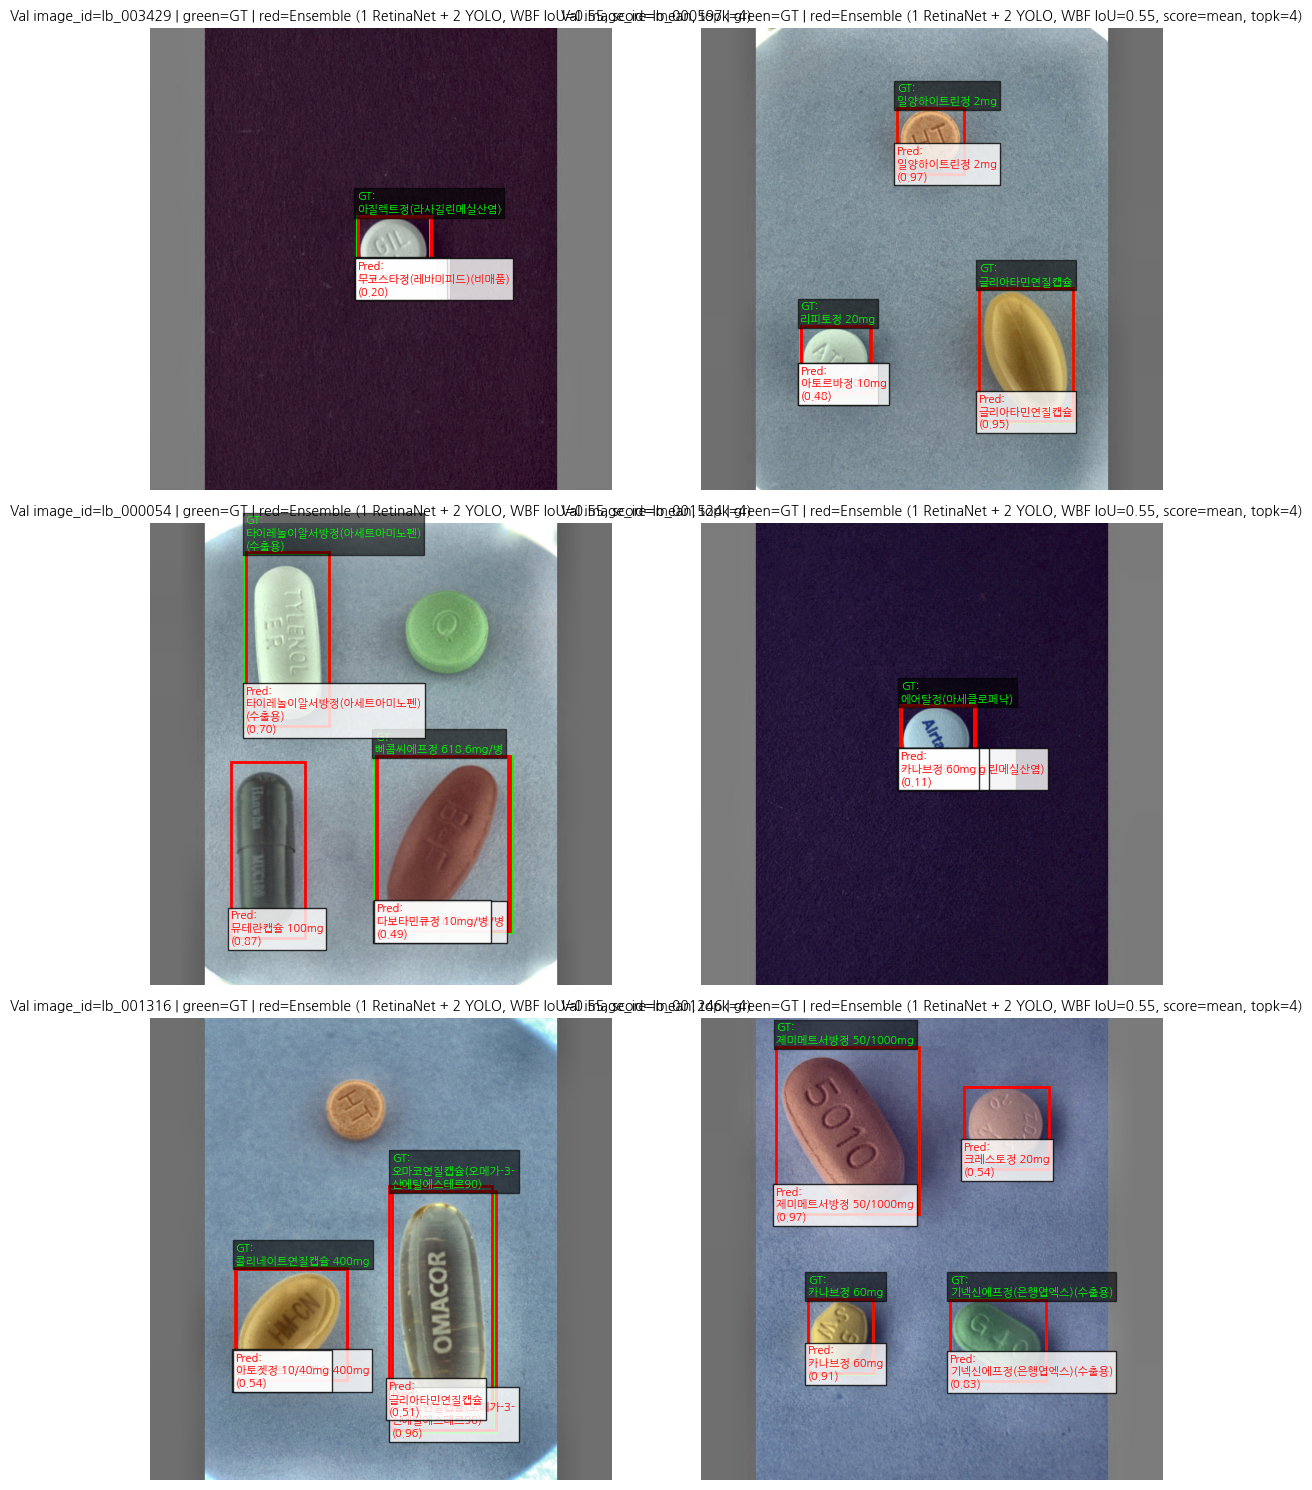

In [8]:
def configure_ensemble_font():
    if IN_COLAB:
        import subprocess

        colab_nanum_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        if not os.path.exists(colab_nanum_path):
            subprocess.run(["apt-get", "update", "-qq"], check=True)
            subprocess.run(["apt-get", "install", "-y", "-qq", "fonts-nanum"], check=True)
            fm._load_fontmanager(try_read_cache=False)

    font_candidates = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    ]

    selected_path = next((path for path in font_candidates if os.path.exists(path)), None)
    if selected_path is None:
        raise FileNotFoundError("한글 폰트를 찾지 못했습니다. Colab에서는 fonts-nanum 설치가 필요합니다.")

    try:
        fm.fontManager.addfont(selected_path)
    except Exception:
        pass

    font_prop = FontProperties(fname=selected_path)
    selected_font = font_prop.get_name()

    plt.rcParams["font.family"] = [selected_font]
    plt.rcParams["font.sans-serif"] = [selected_font, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    return font_prop, selected_font


def wrap_ensemble_label(prefix, name, width=18, score=None):
    wrapped_name = "\n".join(textwrap.wrap(str(name), width=width))
    if score is None:
        return f"{prefix}:\n{wrapped_name}"
    return f"{prefix}:\n{wrapped_name}\n({score:.2f})"


random.seed(RANDOM_SEED)
font_prop, font_name = configure_ensemble_font()
print(f"Visualization font: {font_name}")

sample_image_ids = random.sample(
    list(val_loader.dataset.image_ids),
    k=min(ENSEMBLE_NUM_SAMPLES, len(val_loader.dataset.image_ids)),
)

n_cols = 2
n_rows = max(1, math.ceil(len(sample_image_ids) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, dataset_image_id in zip(axes, sample_image_ids):
    df_img = val_loader.dataset.df[val_loader.dataset.df["image_id"] == dataset_image_id]
    image_path = df_img["image_path"].iloc[0]
    image = Image.open(image_path).convert("RGB")
    img_np = np.array(image)

    retina_pred = predict_retinanet_submission_space(retinanet_model, image_path)
    yolo_member_preds = predict_yolo_members_submission_space(yolo_model_entries, image_path)
    ensemble_pred = ensemble_image_predictions(
        retina_pred,
        *[member["prediction"] for member in yolo_member_preds],
    )

    if ensemble_pred["scores"].numel() > 0:
        keep = ensemble_pred["scores"] >= float(ENSEMBLE_VIS_MIN_SCORE)
        pred_boxes = ensemble_pred["boxes"][keep]
        pred_scores = ensemble_pred["scores"][keep]
        pred_labels = ensemble_pred["labels"][keep]
    else:
        pred_boxes = ensemble_pred["boxes"]
        pred_scores = ensemble_pred["scores"]
        pred_labels = ensemble_pred["labels"]

    ax.imshow(img_np)
    ax.axis("off")

    for _, row in df_img.iterrows():
        x1 = float(row["bbox_x"])
        y1 = float(row["bbox_y"])
        x2 = x1 + float(row["bbox_w"])
        y2 = y1 + float(row["bbox_h"])
        orig_cat = int(row["category_id"])
        pill_name = cat_id_to_name.get(orig_cat, str(orig_cat))

        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="lime", facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            x1, max(y1 - 5, 5),
            wrap_ensemble_label("GT", pill_name, width=18),
            color="lime",
            fontsize=8,
            bbox=dict(facecolor="black", alpha=0.6, pad=2),
            fontproperties=font_prop,
        )

    for box, score, label in zip(pred_boxes, pred_scores, pred_labels):
        x1, y1, x2, y2 = box.tolist()
        orig_cat = int(label.item()) - CATEGORY_ID_OFFSET
        pill_name = cat_id_to_name.get(orig_cat, str(orig_cat))

        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="red", facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            x1, min(y2 + 12, img_np.shape[0] - 5),
            wrap_ensemble_label("Pred", pill_name, width=18, score=float(score.item())),
            color="red",
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.8, pad=2),
            fontproperties=font_prop,
        )

    ax.set_title(
        (
            f"Val image_id={dataset_image_id} | green=GT | red=Ensemble "
            f"(1 RetinaNet + {len(yolo_model_entries)} YOLO, WBF IoU={ENSEMBLE_WBF_IOU:.2f}, score={ENSEMBLE_SCORE_REDUCTION}, topk={TOP_K_PER_IMAGE})"
        ),
        fontproperties=font_prop,
    )

for ax in axes[len(sample_image_ids):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [9]:
import os
import shutil

SAVE_DIR = "/content/drive/MyDrive/pill_detection_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

shutil.copy("/content/pill_detection_project/retinanet_yolo_ensemble_submission.csv", SAVE_DIR)

print(os.listdir(SAVE_DIR))

['retinanet_v9.pth', 'retinanet_oral_drug.pth', 'history_retinanet.json', 'retinanet_test_submission.csv', 'yolo11m_v2_v3_ft_uf_lr_0p0005_best.pt', 'yolov8s_v2_v3_ft_uf_lr_0p0003_best.pt', 'retinanet_yolo_ensemble_submission(1).csv', 'retinanet_yolo_ensemble_submission.csv']


In [10]:
if "df_ensemble_val_sweep" not in globals() or df_ensemble_val_sweep.empty:
    raise RuntimeError("df_ensemble_val_sweep가 비어 있습니다. 먼저 validation sweep 셀을 실행해주세요.")

best_config = df_ensemble_val_sweep.iloc[0]

best_output_csv_path = OUTPUT_CSV_PATH.replace(".csv", "_best_val_sweep.csv")
best_copy_path = None

current_ensemble_config = {
    "RETINANET_SCORE_THRESHOLD": RETINANET_SCORE_THRESHOLD,
    "YOLO_SCORE_THRESHOLD": YOLO_SCORE_THRESHOLD,
    "ENSEMBLE_WBF_IOU": ENSEMBLE_WBF_IOU,
    "ENSEMBLE_SCORE_REDUCTION": ENSEMBLE_SCORE_REDUCTION,
    "TOP_K_PER_IMAGE": TOP_K_PER_IMAGE,
    "POST_WBF_AGNOSTIC_NMS_IOU": POST_WBF_AGNOSTIC_NMS_IOU,
}

try:
    RETINANET_SCORE_THRESHOLD = float(best_config["retinanet_score_threshold"])
    YOLO_SCORE_THRESHOLD = float(best_config["yolo_score_threshold"])
    ENSEMBLE_WBF_IOU = float(best_config["wbf_iou"])
    ENSEMBLE_SCORE_REDUCTION = str(best_config["score_reduction"])
    TOP_K_PER_IMAGE = None if pd.isna(best_config["top_k_per_image"]) else int(best_config["top_k_per_image"])
    POST_WBF_AGNOSTIC_NMS_IOU = None if pd.isna(best_config["post_wbf_agnostic_nms_iou"]) else float(best_config["post_wbf_agnostic_nms_iou"])

    print("Using best validation sweep config:")
    print(best_config[[
        "retinanet_score_threshold",
        "yolo_score_threshold",
        "wbf_iou",
        "score_reduction",
        "post_wbf_agnostic_nms_iou",
        "top_k_per_image",
        "mAP@75:95",
        "mAP@50",
        "num_predictions",
    ]])

    if not os.path.isdir(TEST_IMG_DIR):
        raise FileNotFoundError(f"test_images folder not found: {TEST_IMG_DIR}")

    test_files = sorted(
        f for f in os.listdir(TEST_IMG_DIR)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    )
    if not test_files:
        raise FileNotFoundError(f"No test images found in: {TEST_IMG_DIR}")

    rows = []
    retina_total = 0
    yolo_totals = {entry["name"]: 0 for entry in yolo_model_entries}
    ensemble_total = 0

    for f in test_files:
        img_path = os.path.join(TEST_IMG_DIR, f)
        stem = os.path.splitext(f)[0]
        image_id = int(stem) if stem.isdigit() else stem

        retina_pred = predict_retinanet_submission_space(retinanet_model, img_path)
        yolo_member_preds = predict_yolo_members_submission_space(yolo_model_entries, img_path)
        ensemble_pred = ensemble_image_predictions(
            retina_pred,
            *[member["prediction"] for member in yolo_member_preds],
        )

        retina_total += len(retina_pred["scores"])
        for member in yolo_member_preds:
            yolo_totals[member["name"]] += len(member["prediction"]["scores"])
        ensemble_total += len(ensemble_pred["scores"])

        for box, score, label in zip(
            ensemble_pred["boxes"],
            ensemble_pred["scores"],
            ensemble_pred["labels"],
        ):
            x1, y1, x2, y2 = box.tolist()
            rows.append({
                "image_id": image_id,
                "category_id": int(label.item()),
                "bbox_x": float(x1),
                "bbox_y": float(y1),
                "bbox_w": float(x2 - x1),
                "bbox_h": float(y2 - y1),
                "score": float(score.item()),
            })

    if not rows:
        print("No ensemble predictions were generated.")
        df_sub_best = pd.DataFrame(columns=[
            "annotation_id", "image_id", "category_id",
            "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score",
        ])
    else:
        df_sub_best = pd.DataFrame(rows, columns=[
            "image_id", "category_id",
            "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score",
        ])
        df_sub_best = df_sub_best.sort_values(by=["image_id", "score"], ascending=[True, False])
        df_sub_best.insert(0, "annotation_id", range(1, len(df_sub_best) + 1))

    df_sub_best.to_csv(best_output_csv_path, index=False)
    print(f"Saved best-sweep csv: {best_output_csv_path}")
    print(f"RetinaNet boxes kept(before fusion top-k): {retina_total}")
    for model_name, total in yolo_totals.items():
        print(f"{model_name} boxes kept(before fusion top-k): {total}")
    print(f"Ensemble boxes saved: {ensemble_total}")
    print(
        f"RetinaNet score>={RETINANET_SCORE_THRESHOLD:.2f}, "
        f"YOLO score>={YOLO_SCORE_THRESHOLD:.2f}, "
        f"WBF IoU={ENSEMBLE_WBF_IOU:.2f}, score={ENSEMBLE_SCORE_REDUCTION}, "
        f"post-NMS={POST_WBF_AGNOSTIC_NMS_IOU}, TOP_K={TOP_K_PER_IMAGE}"
    )

    if "SAVE_DIR" in globals() and os.path.isdir(SAVE_DIR):
        import shutil

        best_copy_path = os.path.join(SAVE_DIR, os.path.basename(best_output_csv_path))
        shutil.copy(best_output_csv_path, best_copy_path)
        print(f"Copied best-sweep csv to: {best_copy_path}")
finally:
    RETINANET_SCORE_THRESHOLD = current_ensemble_config["RETINANET_SCORE_THRESHOLD"]
    YOLO_SCORE_THRESHOLD = current_ensemble_config["YOLO_SCORE_THRESHOLD"]
    ENSEMBLE_WBF_IOU = current_ensemble_config["ENSEMBLE_WBF_IOU"]
    ENSEMBLE_SCORE_REDUCTION = current_ensemble_config["ENSEMBLE_SCORE_REDUCTION"]
    TOP_K_PER_IMAGE = current_ensemble_config["TOP_K_PER_IMAGE"]
    POST_WBF_AGNOSTIC_NMS_IOU = current_ensemble_config["POST_WBF_AGNOSTIC_NMS_IOU"]


Using best validation sweep config:
retinanet_score_threshold        0.05
yolo_score_threshold              0.2
wbf_iou                          0.55
score_reduction                  mean
post_wbf_agnostic_nms_iou         NaN
top_k_per_image                     4
mAP@75:95                    0.906978
mAP@50                       0.918285
num_predictions                  1312
Name: 0, dtype: object
Saved best-sweep csv: /content/pill_detection_project/retinanet_yolo_ensemble_submission_best_val_sweep.csv
RetinaNet boxes kept(before fusion top-k): 52859
yolo11m_v2_v3_ft_uf_lr_0p0005 boxes kept(before fusion top-k): 2386
yolov8s_v2_v3_ft_uf_lr_0p0003 boxes kept(before fusion top-k): 2042
Ensemble boxes saved: 3372
RetinaNet score>=0.05, YOLO score>=0.20, WBF IoU=0.55, score=mean, post-NMS=None, TOP_K=4
Copied best-sweep csv to: /content/drive/MyDrive/pill_detection_outputs/retinanet_yolo_ensemble_submission_best_val_sweep.csv
